##### Adaboost from scratch 


In [115]:
import pandas as pd 
import numpy as np
from mlxtend.plotting import plot_decision_regions

In [116]:
# generate own dataset for practise 

df = pd.DataFrame()

df['X1'] = [1,2,3,4,5,6,6,7,9,9]
df['X2'] = [5,3,6,8,1,9,5,8,9,2]
df['label'] = [1,1,0,1,0,1,0,1,0,0]


df

,X1,X2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


we learnt adabosst we use something called decision stump - that is simply a decison tree with max depth 1.. 

and about weak learner- algorithsm whose accuracy is jsut over 50% .(very low)

and in adaboost istead of 1 and 0 as in binary classifiction there is -1 and +1. 

now we have got our data first we will train a decision stump on it .. (we wil take 3 alltogether )

In [117]:
# first assign weight to the data
df.shape

(10, 3)

In [118]:
weight=1/df.shape[0]
df['weight']=weight

In [119]:
df

,X1,X2,label,weight
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [120]:
from sklearn.tree import DecisionTreeClassifier

X=df.drop(['label','weight'],axis=1).values
y=df['label'].values
# we are doing manually to understnd so no need train test split
dt1=DecisionTreeClassifier(max_depth=1)


In [121]:
dt1.fit(X,y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [122]:
# now we will put the ypred in data and see mistakes/missclassification 
ypred=dt1.predict(X)
df['y_pred']=ypred
df

,X1,X2,label,weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


[Text(0.5, 0.75, 'x[1] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [3, 5]'),
 Text(0.625, 0.5, '  False')]

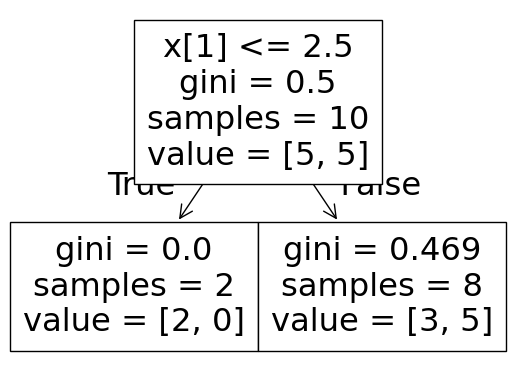

In [123]:
# lets see what dt1 used and how ti performed 

from sklearn.tree import plot_tree
plot_tree(dt1)

In [124]:
df

,X1,X2,label,weight,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,1
3,4,8,1,0.1,1
4,5,1,0,0.1,0
5,6,9,1,0.1,1
6,6,5,0,0.1,1
7,7,8,1,0.1,1
8,9,9,0,0.1,1
9,9,2,0,0.1,0


<Axes: >

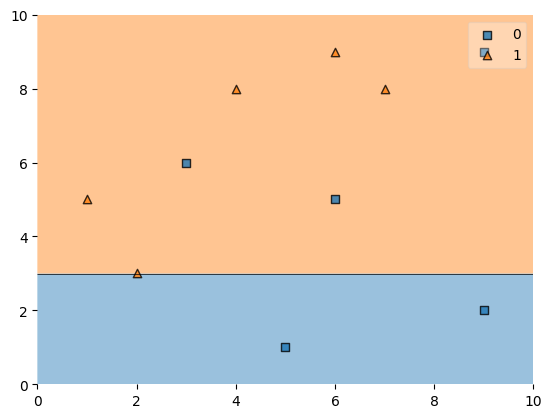

In [125]:
plot_decision_regions(X,y,clf=dt1)

so here about 2 blue points were miss classified from figure .. and one point is in boundary .. 

from table , above table we see 3 missclassification.. so we will make a function which will calculate error first .... 

In [126]:
def error_alpha(error):
    return 0.5*np.log((1-error)/(error)) # funciton 1/2 *ln(1-error/error )


In [127]:
alpha1=error_alpha(0.3)
print(alpha1)

# we calculated alpha i,e weight of the first model/stump 

0.42364893019360184


In [128]:
''' Now we learnt, that for sucessful classificaion we decrease the wt. and for error we incerase the weight 
inorder to make it more focused so that another stump can be careful and try solve it '''

# Step 4 - Update weights
def update_row_weights(row,alpha=0.423):
  if row['label'] == row['y_pred']: # correct classificaion
    return row['weight'] * np.exp(-alpha) # decrease
  else:
    return row['weight'] * np.exp(alpha)


df['updated_weight']=df.apply(update_row_weights,axis=1)
df

,X1,X2,label,weight,y_pred,updated_weight
0,1,5,1,0.1,1,0.065508
1,2,3,1,0.1,1,0.065508
2,3,6,0,0.1,1,0.152653
3,4,8,1,0.1,1,0.065508
4,5,1,0,0.1,0,0.065508
5,6,9,1,0.1,1,0.065508
6,6,5,0,0.1,1,0.152653
7,7,8,1,0.1,1,0.065508
8,9,9,0,0.1,1,0.152653
9,9,2,0,0.1,0,0.065508


In [129]:
df['updated_weight'].sum()
# but we learnt sum should be one so we normalize it by / by sum 

np.float64(0.9165153319682015)

In [130]:
df['normalized']=df['updated_weight']/df['updated_weight'].sum()

In [131]:
df

,X1,X2,label,weight,y_pred,updated_weight,normalized
0,1,5,1,0.1,1,0.065508,0.071475
1,2,3,1,0.1,1,0.065508,0.071475
2,3,6,0,0.1,1,0.152653,0.166559
3,4,8,1,0.1,1,0.065508,0.071475
4,5,1,0,0.1,0,0.065508,0.071475
5,6,9,1,0.1,1,0.065508,0.071475
6,6,5,0,0.1,1,0.152653,0.166559
7,7,8,1,0.1,1,0.065508,0.071475
8,9,9,0,0.1,1,0.152653,0.166559
9,9,2,0,0.1,0,0.065508,0.071475


In [132]:
df['normalized'].sum() # sum is 1 .. 

np.float64(1.0)

In [133]:
# create ranges now 


df['cumsum_upper'] = np.cumsum(df['normalized'])
     

df['cumsum_lower'] = df['cumsum_upper'] - df['normalized']
     

df[['X1','X2','label','weight','y_pred','updated_weight','cumsum_lower','cumsum_upper']]
     

,X1,X2,label,weight,y_pred,updated_weight,cumsum_lower,cumsum_upper
0,1,5,1,0.1,1,0.065508,0.000000,0.071475
1,2,3,1,0.1,1,0.065508,0.071475,0.142950
2,3,6,0,0.1,1,0.152653,0.142950,0.309508
3,4,8,1,0.1,1,0.065508,0.309508,0.380983
4,5,1,0,0.1,0,0.065508,0.380983,0.452458
5,6,9,1,0.1,1,0.065508,0.452458,0.523933
6,6,5,0,0.1,1,0.152653,0.523933,0.690492
7,7,8,1,0.1,1,0.065508,0.690492,0.761967
8,9,9,0,0.1,1,0.152653,0.761967,0.928525
9,9,2,0,0.1,0,0.065508,0.928525,1.000000


In [134]:
# now we generate some random number and see in which range do it fall 

def create_new_dataset(df):

  indices = []

  for i in range(df.shape[0]):
    a = np.random.random()
    for index,row in df.iterrows():
      if row['cumsum_upper'] > a and a > row['cumsum_lower']:
        indices.append(index)
  return indices


In [135]:

index_values = create_new_dataset(df)
index_values


# Now in dataset we will only keep these datasets nothign else will be there 

[5, 0, 8, 0, 5, 4, 8, 2, 0, 8]

In [136]:

second_df = df.iloc[index_values,[0,1,2,3]]
second_df

,X1,X2,label,weight
5,6,9,1,0.1
0,1,5,1,0.1
8,9,9,0,0.1
0,1,5,1,0.1
5,6,9,1,0.1
4,5,1,0,0.1
8,9,9,0,0.1
2,3,6,0,0.1
0,1,5,1,0.1
8,9,9,0,0.1


In [137]:

dt2 = DecisionTreeClassifier(max_depth=1)
     

X_new = second_df.iloc[:,0:2].values
y_new = second_df.iloc[:,2].values

dt2.fit(X_new,y_new)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

<Axes: >

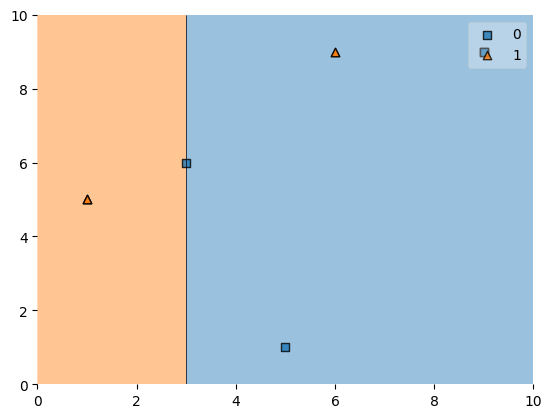

In [138]:
plot_decision_regions(X_new,y_new,clf=dt2)

from graph 1 point misclassifed 1 , 1 sin boundary 

In [139]:
ypred_new=dt2.predict(X_new)

In [140]:
second_df['ypred2']=ypred_new
second_df

,X1,X2,label,weight,ypred2
5,6,9,1,0.1,0
0,1,5,1,0.1,1
8,9,9,0,0.1,0
0,1,5,1,0.1,1
5,6,9,1,0.1,0
4,5,1,0,0.1,0
8,9,9,0,0.1,0
2,3,6,0,0.1,0
0,1,5,1,0.1,1
8,9,9,0,0.1,0


1 misclassification  seen so agian we will do the same thign as above 

In [141]:
# calc alpha 

alpha2=error_alpha(0.1)
alpha2

np.float64(1.0986122886681098)

In [142]:

# Step 4 - Update weights
def update_row_weights(row,alpha=1.098612):
  if row['label'] == row['ypred2']:
    return row['weight'] * np.exp(-alpha)
  else:
    return row['weight'] * np.exp(alpha)

second_df['updated_weight']=second_df.apply(update_row_weights,axis=1)

In [143]:
second_df

,X1,X2,label,weight,ypred2,updated_weight
5,6,9,1,0.1,0,0.300000
0,1,5,1,0.1,1,0.033333
8,9,9,0,0.1,0,0.033333
0,1,5,1,0.1,1,0.033333
5,6,9,1,0.1,0,0.300000
4,5,1,0,0.1,0,0.033333
8,9,9,0,0.1,0,0.033333
2,3,6,0,0.1,0,0.033333
0,1,5,1,0.1,1,0.033333
8,9,9,0,0.1,0,0.033333


In [144]:
# normalize
second_df['nomalized_weight'] = second_df['updated_weight']/second_df['updated_weight'].sum()


    
second_df['cumsum_upper'] = np.cumsum(second_df['nomalized_weight'])
     

second_df['cumsum_lower'] = second_df['cumsum_upper'] - second_df['nomalized_weight']
     

second_df[['X1','X2','label','weight','ypred2','nomalized_weight','cumsum_lower','cumsum_upper']]


,X1,X2,label,weight,ypred2,nomalized_weight,cumsum_lower,cumsum_upper
5,6,9,1,0.1,0,0.346154,0.000000,0.346154
0,1,5,1,0.1,1,0.038462,0.346154,0.384615
8,9,9,0,0.1,0,0.038462,0.384615,0.423077
0,1,5,1,0.1,1,0.038462,0.423077,0.461538
5,6,9,1,0.1,0,0.346154,0.461538,0.807692
4,5,1,0,0.1,0,0.038462,0.807692,0.846154
8,9,9,0,0.1,0,0.038462,0.846154,0.884615
2,3,6,0,0.1,0,0.038462,0.884615,0.923077
0,1,5,1,0.1,1,0.038462,0.923077,0.961538
8,9,9,0,0.1,0,0.038462,0.961538,1.000000


In [145]:
new_indices=create_new_dataset(second_df)
new_indices

[5, 5, 8, 5, 5, 5, 0, 5, 8, 8]

In [146]:

third_df = second_df.iloc[new_indices,[0,1,2,3]]
third_df

,X1,X2,label,weight
4,5,1,0,0.1
4,5,1,0,0.1
0,1,5,1,0.1
4,5,1,0,0.1
4,5,1,0,0.1
4,5,1,0,0.1
5,6,9,1,0.1
4,5,1,0,0.1
0,1,5,1,0.1
0,1,5,1,0.1


In [147]:

dt3 = DecisionTreeClassifier(max_depth=1)

X_third= third_df.iloc[:,0:2].values
y_third = third_df.iloc[:,2].values

dt3.fit(X_third,y_third)
     

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

<Axes: >

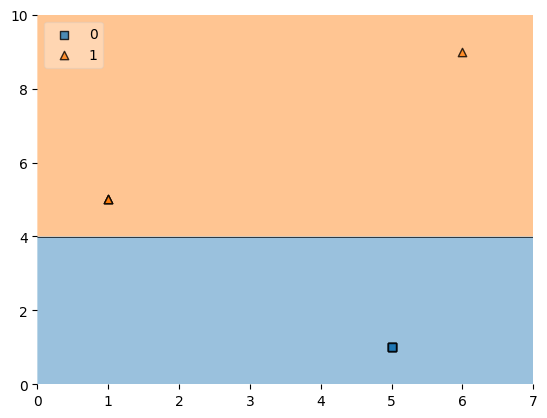

In [148]:

plot_decision_regions(X_third, y_third, clf=dt3, legend=2)
     

In [149]:

third_df['y_pred'] = dt3.predict(X_third)
     

third_df


,X1,X2,label,weight,y_pred
4,5,1,0,0.1,0
4,5,1,0,0.1,0
0,1,5,1,0.1,1
4,5,1,0,0.1,0
4,5,1,0,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,1
4,5,1,0,0.1,0
0,1,5,1,0.1,1
0,1,5,1,0.1,1


In [150]:
alpha3=error_alpha(0.3)
alpha3

np.float64(0.42364893019360184)

predection

In [151]:
query = np.array([1,5]).reshape(1,2)
dt1.predict(query)
     

array([1])

In [152]:
dt2.predict(query)


array([1])

In [153]:
dt3.predict(query)

array([1])

In [154]:

alpha1*(1) + alpha2*(-1) + alpha3*(-1)
     

np.float64(-1.0986122886681098)

In [155]:
np.sign(-1.098)

np.float64(-1.0)